In [1]:
import os
import re
import glob
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Global cache: avoid re-loading .npz on every residual call
# ------------------------------------------------------------
_flat_cache = {}

def load_flatpack(k_index, flat_dir="lambda_singlet"):
    """
    Load and cache flat-band data for a given k_index.
    Expects files named flat_kXXXXX.npz inside flat_dir.
    """
    k_index = int(k_index)
    key = (flat_dir, k_index)
    if key in _flat_cache:
        return _flat_cache[key]

    path = os.path.join(flat_dir, f"flat_k{k_index:05d}.npz")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    z = np.load(path, allow_pickle=True)
    pack = {
        "L0flat":     z["L0flat"],          # shape: (3, N, N)
        "L1flat":     z["L1flat"],          # shape: (3, N, N)
        "Eplus_flat":  z["Eplus_flat"],     # shape: (N,)
        "Eminus_flat": z["Eminus_flat"],    # shape: (N,)
        "k":          z["k"],
        "k_index":    int(z["k_index"]),
    }
    _flat_cache[key] = pack
    return pack

# ------------------------------------------------------------
# Helper: centered subspace indices
# ------------------------------------------------------------
def _center_indices(N, subspace_dim):
    """
    Return indices for a centered subspace of size subspace_dim inside 0..N-1.
    """
    if subspace_dim > N:
        raise ValueError(f"subspace_dim={subspace_dim} > full dim N={N}")
    start = (N - subspace_dim) // 2
    end   = start + subspace_dim
    return np.arange(start, end, dtype=int)

# ------------------------------------------------------------
# Flat-band BdG Hamiltonian (restricted subspace)
# ------------------------------------------------------------
def flat_BdG(pack, *, DeltaLayer0, DeltaLayer1, mu,
             subspace_dim=10):
    """
    Build flat-band BdG Hamiltonian in a centered subspace of size subspace_dim.
    Δ0, Δ1 are length-3 complex arrays (one component per Kekulé irrep).
    """
    Δ0 = np.asarray(DeltaLayer0, complex).ravel()
    Δ1 = np.asarray(DeltaLayer1, complex).ravel()
    if Δ0.size != 3 or Δ1.size != 3:
        raise ValueError("DeltaLayer0/1 must each have length 3.")

    Eplus  = np.asarray(pack["Eplus_flat"],  float)
    Eminus = np.asarray(pack["Eminus_flat"], float)
    L0flat = np.asarray(pack["L0flat"])   # (3, N, N)
    L1flat = np.asarray(pack["L1flat"])   # (3, N, N)

    N = Eplus.shape[0]
    idx = _center_indices(N, subspace_dim)

    # restrict to subspace
    Eplus_sub  = Eplus[idx]
    Eminus_sub = Eminus[idx]
    L0_sub = L0flat[:, idx][:, :, idx]   # (3, subspace_dim, subspace_dim)
    L1_sub = L1flat[:, idx][:, :, idx]   # (3, subspace_dim, subspace_dim)

    Fp = np.diag(Eplus_sub)
    Fm = -np.diag(Eminus_sub)

    # pairing: here only sym = 0 component used; Lflat is mathematical Λ
    Gap_flat = Δ0[0] * np.conj(L0_sub[0]) + Δ1[0] * np.conj(L1_sub[0])

    I = np.eye(Fp.shape[0], dtype=complex)
    HLL = np.block([
        [Fp - mu * I,          Gap_flat        ],
        [Gap_flat.conj().T,    Fm + mu * I     ]
    ]).astype(complex)

    return HLL, Gap_flat, np.diag(Eminus_sub)

# ------------------------------------------------------------
# Lambda in flat subspace
# ------------------------------------------------------------
def Lambda_Flat(pack_flat, *, layer=0, sym=0, subspace_dim=10):
    """
    Return Λ (conjugated) in the same centered subspace as flat_BdG.
    Mathematical Λ = Lflat[sym]. Here we return conj(Λ) so that
    np.vdot(Lambda, F) = tr(Λ^T F).
    """
    Lflat_all = np.asarray(pack_flat["L0flat" if layer == 0 else "L1flat"])
    Lfull_math = Lflat_all[sym]              # Λ_math, shape (N, N)
    Lambda_full = np.conj(Lfull_math)        # Λ_code = conj(Λ_math)

    N = Lambda_full.shape[0]
    idx = _center_indices(N, subspace_dim)
    Lambda = Lambda_full[idx][:, idx]        # (subspace_dim, subspace_dim)
    return Lambda

# ------------------------------------------------------------
# Anomalous correlator F
# ------------------------------------------------------------
def Anomalous(pack, *, DeltaLayer0, DeltaLayer1, mu, T=1e-3,
              subspace_dim=10):
    """
    Compute anomalous correlator F = G_{12} in the truncated subspace.
    Uses Matsubara-like tanh kernel: t = -1/2 tanh(βE/2).
    """
    HLL, _,_ = flat_BdG(pack, DeltaLayer0=DeltaLayer0,
                      DeltaLayer1=DeltaLayer1,
                      mu=mu, subspace_dim=subspace_dim)
    E, U = np.linalg.eigh(HLL)

    beta = 1.0 / float(T)
    x = 0.5 * beta * np.asarray(E)
    t = -0.5 * np.tanh(x)
    G = (U * t) @ U.conj().T
    n = HLL.shape[0] // 2
    F = G[:n, n:]   # particle-hole block
    return F, (E, U)

# ------------------------------------------------------------
# Stable Fermi function using tanh (no overflow)
# ------------------------------------------------------------
def fermi_occupation(E, T):
    """
    f(E) = 1/(1 + exp(βE)) = 0.5 * (1 - tanh(βE/2)), stable for large βE.
    """
    beta = 1.0 / float(T)
    x = 0.5 * beta * np.asarray(E)
    return 0.5 * (1.0 - np.tanh(x))

# ------------------------------------------------------------
# Brillouin-zone integration: gap contractions + density
# ------------------------------------------------------------
def IntegrateBZ_acc(*, DeltaLayer0, DeltaLayer1, mu,
                    sym=0, T=1e-3,
                    flat_dir="lambda_singlet",
                    average=True,
                    subspace_dim=10):
    """
    Loop over all k-points in flat_dir and accumulate:
        acc0 = <Λ0, F>
        acc1 = <Λ1, F>
        n    = particle density
    Everything is done in one BZ sweep using the same (E, U).
    """
    files = sorted(
        fn for fn in os.listdir(flat_dir)
        if re.match(r"flat_k\d{5}\.npz$", fn)
    )
    if not files:
        raise FileNotFoundError(f"No flat_kXXXXX.npz files found in {flat_dir}")

    acc0 = 0j
    acc1 = 0j
    total_n = 0.0
    Nk = 0

    for fn in files:
        k_index = int(fn[6:11])
        pack = load_flatpack(k_index, flat_dir=flat_dir)

        # anomalous block + spectrum
        F, (E, U) = Anomalous(
            pack,
            DeltaLayer0=DeltaLayer0,
            DeltaLayer1=DeltaLayer1,
            mu=mu, T=T,
            subspace_dim=subspace_dim
        )

        # gap contractions: Gamma = conj(Λ_math)
        Gamma0 = Lambda_Flat(pack, layer=0, sym=sym, subspace_dim=subspace_dim)
        Gamma1 = Lambda_Flat(pack, layer=1, sym=sym, subspace_dim=subspace_dim)
        # np.vdot(Gamma, F) = sum conj(Gamma)*F = sum Λ_math * F = tr(Λ_math^T F)
        acc0 += np.vdot(Gamma0, F)
        acc1 += np.vdot(Gamma1, F)

        # density from same E, U
        fE = fermi_occupation(E, T)
        G_occ = (U * fE) @ U.conj().T
        n_sub = F.shape[0]          # particle-block dimension in subspace
        n_k = float(np.trace(G_occ[:n_sub, :n_sub]).real)
        total_n += n_k

        Nk += 1

    if average and Nk:
        acc0 /= Nk
        acc1 /= Nk
        total_n /= Nk

    return acc0, acc1, total_n

# ------------------------------------------------------------
# ParticleMomentum (if you still want it separately)
# ------------------------------------------------------------
def ParticleMomentum(pack, *, DeltaLayer0, DeltaLayer1,
                     mu=0.0, T=1e-3, subspace_dim=10):
    """
    Compute particle-block correlator G_11 at a single k.
    """
    HLL, _ = flat_BdG(pack, DeltaLayer0=DeltaLayer0,
                      DeltaLayer1=DeltaLayer1,
                      mu=mu, subspace_dim=subspace_dim)
    E, U = np.linalg.eigh(HLL)
    fE = fermi_occupation(E, T)
    G = (U * fE) @ U.conj().T
    n = HLL.shape[0] // 2
    Gfirst = G[:n, :n]
    return Gfirst, (E, U)

# ------------------------------------------------------------
# Particle number over BZ as a wrapper
# ------------------------------------------------------------
def particle_number_BZ(*, DeltaLayer0, DeltaLayer1, mu=0.0, T=1e-3,
                       flat_dir="lambda_singlet", average=True,
                       subspace_dim=10):
    """
    Wrapper using IntegrateBZ_acc to get density only.
    """
    _, _, n = IntegrateBZ_acc(
        DeltaLayer0=DeltaLayer0,
        DeltaLayer1=DeltaLayer1,
        mu=mu,
        sym=0,
        T=T,
        flat_dir=flat_dir,
        average=average,
        subspace_dim=subspace_dim
    )
    return n

# ------------------------------------------------------------
# Solve gap + density at fixed V
# ------------------------------------------------------------
def solve_gap_density_free(*, sym=0, V=-1.0, T=1e-3, mu_init=0.0,
                           flat_dir="lambda_singlet",
                           x0=(5e-2, 0.0, -5e-2, 0.0),  # (ReΔ0, ImΔ0, ReΔ1, ImΔ1)
                           n_target=3.0/8.0,
                           max_nfev=800, verbose=True,
                           subspace_dim=10):
    """
    Solve for (Δ0, Δ1, μ) such that:
      Δ0 = V * acc0, Δ1 = V * acc1, n = n_target.
    """
    x0 = np.asarray([x0[0], x0[1], x0[2], x0[3], float(mu_init)], float)

    def residuals(x):
        d0 = complex(x[0], x[1])
        d1 = complex(x[2], x[3])
        mu = float(x[4])

        Δ0_vec = np.zeros(3, complex)
        Δ1_vec = np.zeros(3, complex)
        Δ0_vec[sym] = d0
        Δ1_vec[sym] = d1

        acc0, acc1, n = IntegrateBZ_acc(
            DeltaLayer0=Δ0_vec,
            DeltaLayer1=Δ1_vec,
            mu=mu,
            sym=sym,
            T=T,
            flat_dir=flat_dir,
            average=True,
            subspace_dim=subspace_dim
        )

        # gap equations (complex -> 4 real equations)
        r0 = d0 - V * acc0
        r1 = d1 - V * acc1
        # number equation
        rn = n - n_target

        return np.array([r0.real, r0.imag, r1.real, r1.imag, rn], float)

    ls = least_squares(
        residuals, x0, method="trf",
        ftol=1e-8, xtol=1e-8, gtol=1e-8,
        max_nfev=max_nfev
    )

    d0 = complex(ls.x[0], ls.x[1])
    d1 = complex(ls.x[2], ls.x[3])
    mu = float(ls.x[4])

    if verbose:
        print(f"[free] success={ls.success} resnorm={np.linalg.norm(ls.fun):.3e} msg={ls.message}")
        print(f"Δ0={d0:+.6e}, Δ1={d1:+.6e}, μ={mu:+.6e}")

    info = {
        "success": bool(ls.success),
        "resnorm": float(np.linalg.norm(ls.fun)),
        "message": ls.message,
    }
    return (d0, d1, mu), info

# ------------------------------------------------------------
# Sweep over V with continuation
# ------------------------------------------------------------
def sweep_couplings(*, sym=0, T=1e-3, flat_dir="lambda_singlet",
                    n_target=3.0/8.0,
                    V_start=-0.04, V_end=-0.02, npts=20,
                    x0=(5e-2, 0.0, -5e-2, 0.0),  # seed for (ReΔ0, ImΔ0, ReΔ1, ImΔ1)
                    mu0=0.0, max_nfev=800, verbose=True,
                    subspace_dim=10):
    """
    Continuation over V with density constraint n = n_target.
    Uses solve_gap_density_free at each step, seeded by previous solution.
    Returns: list of dicts with V, Δ0, Δ1, μ, n, resnorm, success.
    """
    Vs = np.linspace(V_start, V_end, npts)
    rows = []

    seed_x = tuple(map(float, x0))
    seed_mu = float(mu0)

    for i, V in enumerate(Vs):
        if verbose:
            print(f"\n=== [{i+1}/{len(Vs)}] V = {V:+.6f}, target n = {n_target:.8f} ===")

        (d0, d1, mu), info = solve_gap_density_free(
            sym=sym, V=V, T=T,
            mu_init=seed_mu,
            flat_dir=flat_dir,
            x0=seed_x,
            n_target=n_target,
            max_nfev=max_nfev,
            verbose=verbose,
            subspace_dim=subspace_dim
        )

        # update continuation seeds
        seed_x = (d0.real, d0.imag, d1.real, d1.imag)
        seed_mu = mu

        # evaluate actual n and gap checks with final solution
        Δ0_vec = np.zeros(3, complex)
        Δ1_vec = np.zeros(3, complex)
        Δ0_vec[sym] = d0
        Δ1_vec[sym] = d1

        acc0, acc1, n = IntegrateBZ_acc(
            DeltaLayer0=Δ0_vec,
            DeltaLayer1=Δ1_vec,
            mu=mu,
            sym=sym,
            T=T,
            flat_dir=flat_dir,
            average=True,
            subspace_dim=subspace_dim
        )

        rows.append({
            "V": V,
            "Δ0": d0,
            "Δ1": d1,
            "μ": mu,
            "n": n,
            "resnorm": info["resnorm"],
            "success": info["success"],
            "Δ0_minus_Vacc0": d0 - V * acc0,
            "Δ1_minus_Vacc1": d1 - V * acc1,
        })

        if verbose:
            print(f"Δ0={d0:+.6e}, Δ1={d1:+.6e}, μ={mu:+.6e}, n={n:.8f}")
            print(f"check: Δ0−V*acc0={rows[-1]['Δ0_minus_Vacc0']:+.3e}, "
                  f"Δ1−V*acc1={rows[-1]['Δ1_minus_Vacc1']:+.3e}, "
                  f"resnorm={info['resnorm']:.2e}")

    return rows

# ------------------------------------------------------------
# Example usage / plotting (like your original)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

if __name__ == "__main__":
    sym = 0
    T = 1e-6
    flat_dir = "lambda_singlet"
    subspace_dim = 60
    n_target = 3.0 / 8.0+subspace_dim/2-1
    V_start, V_end, npts = -0.007, -0.003, 5
    prev = (+1.188456e-3, +0.0, +1.188456e-3, -0.0, 0.0)   # (ReΔ0, ImΔ0, ReΔ1, ImΔ1, μ)
    max_nfev = 800
    verbose = True
     

    results = sweep_couplings(
        sym=sym,
        T=T,
        flat_dir=flat_dir,
        n_target=n_target,
        V_start=V_start,
        V_end=V_end,
        npts=npts,
        x0=(prev[0], prev[1], prev[2], prev[3]),
        mu0=prev[4],
        max_nfev=max_nfev,
        verbose=verbose,
        subspace_dim=subspace_dim
    )

    V   = np.array([r["V"]  for r in results], float)
    D0  = np.array([r["Δ0"] for r in results], complex)
    D1  = np.array([r["Δ1"] for r in results], complex)
    MU  = np.array([r["μ"]  for r in results], float)
    NN  = np.array([r["n"]  for r in results], float)
    RES = np.array([r["resnorm"] for r in results], float)

    plt.figure()
    plt.plot(V, np.abs(D0), "o-", label="|Δ0|")
    plt.plot(V, np.abs(D1), "s-", label="|Δ1|")
    plt.xlabel("V")
    plt.ylabel("|Δ|")
    plt.title("Gap magnitudes vs coupling (fixed n)")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== [1/5] V = -0.007000, target n = 29.37500000 ===


KeyboardInterrupt: 

In [2]:
def ParticleEnergy(pack, *, DeltaLayer0, DeltaLayer1,
                   T=1e-3, mu=0.0, subspace_dim=10):
    """
    Energy-weighted correlator for a single k:
      weight = E * f_FD(E) = E / (1 + exp(βE))
    implemented in a numerically stable way using tanh.
    """
    HLL, _,Fm = flat_BdG(pack,
                      DeltaLayer0=DeltaLayer0,
                      DeltaLayer1=DeltaLayer1,
                      mu=mu,
                      subspace_dim=subspace_dim)
    E, U = np.linalg.eigh(HLL)

    beta = 1.0 / float(T)
    x = 0.5 * beta * E
    f_occ = 0.5 * (1.0 - np.tanh(x))  # f_FD(E) = 1/(1+e^{βE})
    weight = E * f_occ                # E f(E)
    ### Ref to Normal State
    xN = 0.5 * beta * Fm
    f_occN= 0.5 * (1.0 - np.tanh(xN))  # f_FD(E) = 1/(1+e^{βE})
    weightNormal = 2*Fm * f_occN
    ###-np.sum(weightNormal)
    return np.sum(weight)+np.sum(Fm), (E, U)

def particle_Energy_BZ(*, DeltaLayer0, DeltaLayer1,
                       T=1e-3, mu=0.0,
                       subspace_dim=10,
                       flat_dir="lambda_singlet",
                       average=True):
    """
    Brillouin-zone average of Tr(Gfirst) over all k in flat_dir.
    Uses ParticleEnergy at each k.
    """
    # clear global cache to avoid memory blow-up from previous sweeps
    #global _flat_cache
    #_flat_cache.clear()

    files = sorted(
        fn for fn in os.listdir(flat_dir)
        if re.match(r"flat_k\d{5}\.npz$", fn)
    )
    if not files:
        raise FileNotFoundError(f"No flat_kXXXXX.npz files found in {flat_dir}")

    total = 0.0
    Nk = 0
    for fn in files:
        k_index = int(fn[6:11])
        pack = load_flatpack(k_index, flat_dir=flat_dir)

        Gfirst, _ = ParticleEnergy(
            pack,
            DeltaLayer0=DeltaLayer0,
            DeltaLayer1=DeltaLayer1,
            T=T,
            mu=mu,
            subspace_dim=subspace_dim
        )

        total += float(Gfirst.real)
        Nk += 1

    if average and Nk:
        total /= Nk
    return total


def Potential_Energy(V, Delta0, Delta1):
    """
    Mean-field interaction energy, per your convention:
      E_pot = -(|Δ0|^2 + |Δ1|^2) / V
    """
    return - (np.abs(Delta0)**2 + np.abs(Delta1)**2) / V

 


In [20]:
    # --- extract basic quantities ---
    #idx = np.array([r["i"]  for r in results], int)
    D0  = np.array([r["Δ0"] for r in results], complex)
    D1  = np.array([r["Δ1"] for r in results], complex)
    MU  = np.array([r["μ"]  for r in results], float)
    #Extra  = np.array([r["extra"]  for r in results], float)
    NN  = np.array([r["n"]  for r in results], float)
    RES = np.array([r["resnorm"] for r in results], float)

    # --- compute energies for ALL solutions ---
    E_kin_list = []
    E_pot_list = []
    E_tot_list = []

    for r in results:
        d0       = r["Δ0"]
        d1       = r["Δ1"]
        mu       = r["μ"]
        #flat_dir = r["flat_dir"]
        V        = r["V"]     

        Δ0_vec = np.zeros(3, complex)
        Δ1_vec = np.zeros(3, complex)
        Δ0_vec[sym] = d0
        Δ1_vec[sym] = d1

        # kinetic/single-particle energy
        E_kin = particle_Energy_BZ(
            DeltaLayer0=Δ0_vec,
            DeltaLayer1=Δ1_vec,
            T=T,
            mu=mu,
            subspace_dim=subspace_dim,
            flat_dir=flat_dir,
            average=True,
        )

        # potential energy
        E_pot = Potential_Energy(V, d0, d1)

        E_chemical= mu *  n_target *2 
        # total
        E_tot = E_kin + E_pot+ E_chemical

        r["E_kin"] = E_kin
        r["E_pot"] = E_pot
        r["E_tot"] = E_tot

        E_kin_list.append(E_kin)
        E_pot_list.append(E_pot)
        E_tot_list.append(E_tot)

    E_kin_arr = np.array(E_kin_list, float)
    E_pot_arr = np.array(E_pot_list, float)
    E_tot_arr = np.array(E_tot_list, float)



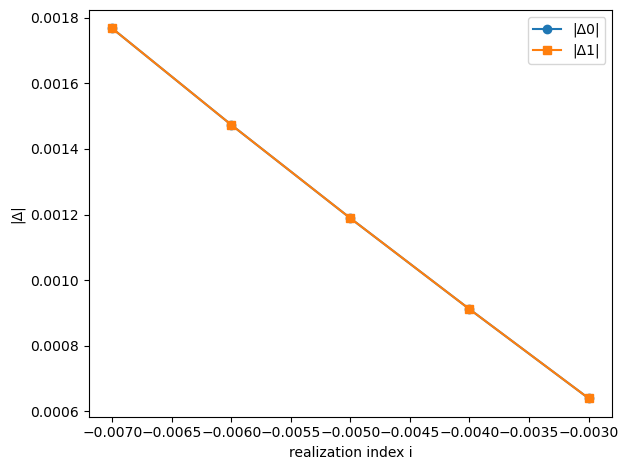

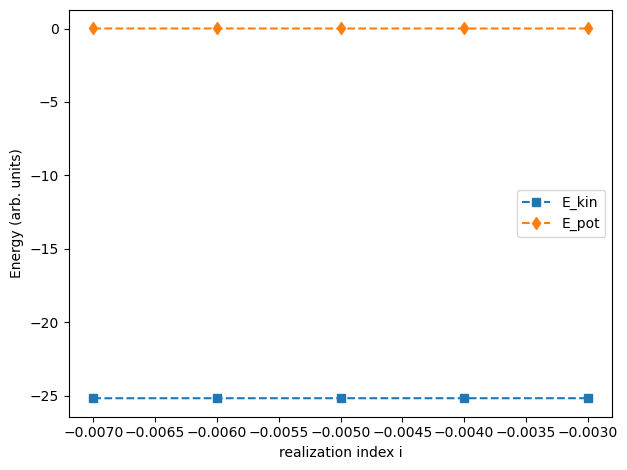

In [21]:
    # --- plots: gaps and energies vs realization index ---
    V   = np.array([r["V"]  for r in results], float)
    plt.figure()
    plt.plot(V, np.abs(D0), "o-", label="|Δ0|")
    plt.plot(V, np.abs(D1), "s-", label="|Δ1|")
    plt.xlabel("realization index i")
    plt.ylabel("|Δ|")
     
    plt.legend()
    plt.tight_layout()

    plt.figure()
    #plt.plot(V, E_tot_arr, "o-", label="E_tot")
    plt.plot(V, E_kin_arr, "s--", label="E_kin")
    plt.plot(V, E_pot_arr, "d--", label="E_pot")
    plt.xlabel("realization index i")
    plt.ylabel("Energy (arb. units)")
    
    plt.legend()
    plt.tight_layout()

    plt.show()

In [23]:
E_tot_arr

array([-25.1405477 , -25.13297131, -25.12584584, -25.11924263,
       -25.11332898])

In [16]:
V

array([-0.007, -0.006, -0.005, -0.004, -0.003])

Grid min at: Re d0 = -0.01 Re d1 = -0.01 dE_min = -0.003480608813161812
Solution point: Re d0 = 0.004689777 Re d1 = -0.004689777 dE=0 by definition


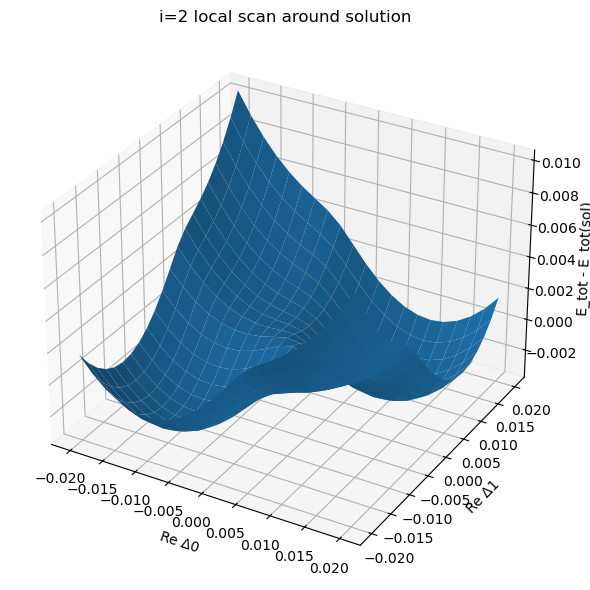

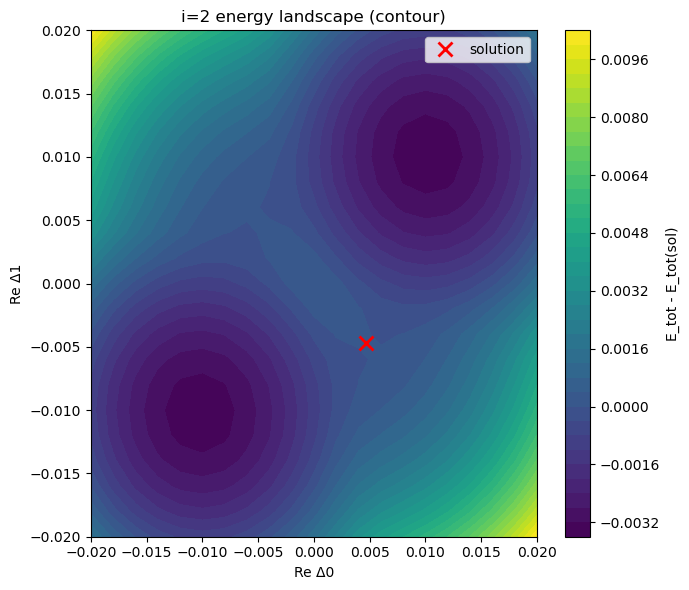

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---- i=2 solution from your log ----
sym = 0
T = 1e-6
V = -0.03
mu = 2.207455e-04
flat_dir = "lambda_singlet"
subspace_dim = 10

d0_sol = 4.689777e-03 - 7.426809e-09j
d1_sol = -4.689777e-03 + 7.426809e-09j

def Etot(d0, d1):
    Δ0_vec = np.zeros(3, complex); Δ1_vec = np.zeros(3, complex)
    Δ0_vec[sym] = d0
    Δ1_vec[sym] = d1
    E_kin = particle_Energy_BZ(
        DeltaLayer0=Δ0_vec, DeltaLayer1=Δ1_vec,
        T=T, mu=mu, subspace_dim=subspace_dim,
        flat_dir=flat_dir, average=True
    )
    E_pot = Potential_Energy(V, d0, d1)
    return float(E_kin + E_pot)

# ---- scan ranges (start coarse, then refine) ----
# your gaps are ~4.7e-3, so +/- 20% is a good first window
span = 0.25 * abs(d0_sol.real)        # adjust: 0.1~0.4
N = 21                                # coarse; try 31/41 after

d0_re = np.linspace(-0.02, 0.02, N)
d1_re = np.linspace(-0.02, 0.02, N)

D0, D1 = np.meshgrid(d0_re, d1_re, indexing="xy")
E = np.empty_like(D0, dtype=float)

# ---- evaluate grid ----
for ix in range(N):
    for iy in range(N):
        d0 = complex(D0[iy, ix], d0_sol.imag)  # fix imag to solved value
        d1 = complex(D1[iy, ix], d1_sol.imag)
        E[iy, ix] = Etot(d0, d1)

# ---- shift by E at solution for readability ----
E0 = Etot(d0_sol, d1_sol)
dE = E - E0

# ---- report grid min ----
min_idx = np.unravel_index(np.argmin(E), E.shape)
print("Grid min at:",
      "Re d0 =", D0[min_idx], "Re d1 =", D1[min_idx],
      "dE_min =", dE[min_idx])

print("Solution point:",
      "Re d0 =", d0_sol.real, "Re d1 =", d1_sol.real, "dE=0 by definition")

# ---- 3D surface ----
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(D0, D1, dE, rstride=1, cstride=1, linewidth=0, antialiased=True)
ax.set_xlabel("Re Δ0")
ax.set_ylabel("Re Δ1")
ax.set_zlabel("E_tot - E_tot(sol)")
ax.set_title("i=2 local scan around solution")
plt.tight_layout()
plt.show()

# ---- 2D contour (often more informative than 3D) ----
plt.figure(figsize=(7, 6))
cs = plt.contourf(D0, D1, dE, levels=40)
plt.colorbar(cs, label="E_tot - E_tot(sol)")
plt.plot([d0_sol.real], [d1_sol.real], "rx", ms=10, mew=2, label="solution")
plt.xlabel("Re Δ0")
plt.ylabel("Re Δ1")
plt.title("i=2 energy landscape (contour)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6,5), dpi=150)
plt.contourf(D0, D1, dE, levels=60, cmap="coolwarm", norm=norm)
plt.colorbar(label="ΔE")
plt.plot([d0_sol.real],[d1_sol.real],"kx",ms=8,mew=2)
plt.xlabel("Re Δ0"); plt.ylabel("Re Δ1")
plt.tight_layout(); plt.show()
